In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

file = pd.read_json("./made_up_stats.json")

# Time cleaning
df = pd.DataFrame(file)
df['timp_folosit_minutes'] = pd.to_timedelta(df['timp_folosit'])
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].dt.total_seconds() / 60
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].round(0)

column_to_move = df.pop('timp_folosit_minutes')
df.insert(2, 'timp_folosit_minutes', column_to_move)

# New column names
info_names = [f"problema_{i}_info" for i in range(1, 11)]
mate_names = [f"problema_{i}_mate" for i in range(1, 11)]

# Populate math answers
mate_df = df.explode('detalii_mate')
expanded_mate = mate_df['detalii_mate'].apply(pd.Series)
correct_mate = expanded_mate['correct']
correct_mate = correct_mate.rename('mate-answer-key')

reshaped_mate = expanded_mate['answer'].values.reshape(-1, 10)
mate_ans = pd.DataFrame(reshaped_mate, columns=mate_names)

# Populate info answers
info_df = df.explode('detalii_info')
expanded_info = info_df['detalii_info'].apply(pd.Series)
correct_info = expanded_info['correct']
correct_info = correct_info.rename('info-answer-key')

reshaped_info = expanded_info['answer'].values.reshape(-1, 10)
info_ans = pd.DataFrame(reshaped_info, columns=info_names)

# Add results together
cleaned_df = df.drop(columns=['detalii_info', 'detalii_mate'])

cleaned_df = cleaned_df.reset_index(drop=True)
correct_info = correct_info.reset_index(drop=True)
correct_mate = correct_mate.reset_index(drop=True)
mate_ans = mate_ans.reset_index(drop=True)
info_ans = info_ans.reset_index(drop=True)

mate_answer_key = pd.Series(correct_mate.iloc[:10].values)
info_answer_key = pd.Series(correct_info.iloc[:10].values)

final_barem = pd.DataFrame({
    'Mate_Answers': mate_answer_key,
    'Info_Answers': info_answer_key
})

final_df = pd.concat([cleaned_df, mate_ans, info_ans], axis=1)


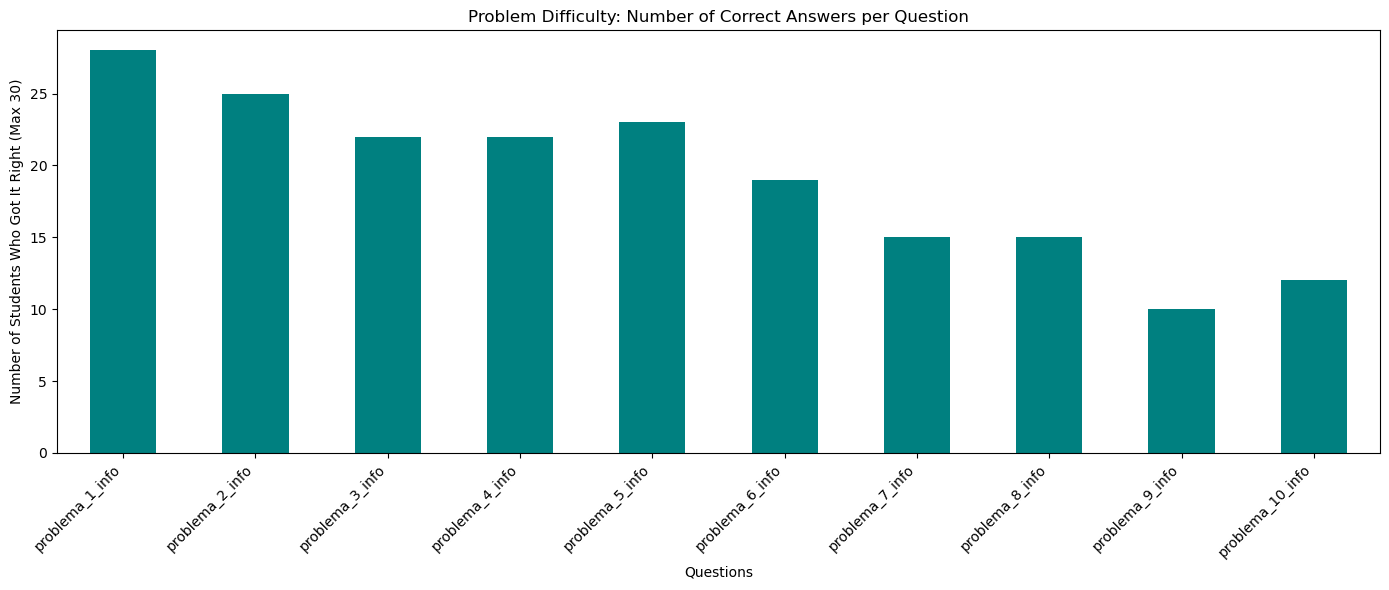

In [176]:
info_answers = final_df.iloc[:, 16:26] 
info_correct = info_answers == info_answer_key.values

info_problem_scores = info_correct.sum(axis=0)

plt.figure(figsize=(14, 6))

info_problem_scores.plot(kind='bar', color='teal')

plt.title('Problem Difficulty: Number of Correct Answers per Question')
plt.ylabel('Number of Students Who Got It Right (Max 30)')
plt.xlabel('Questions')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

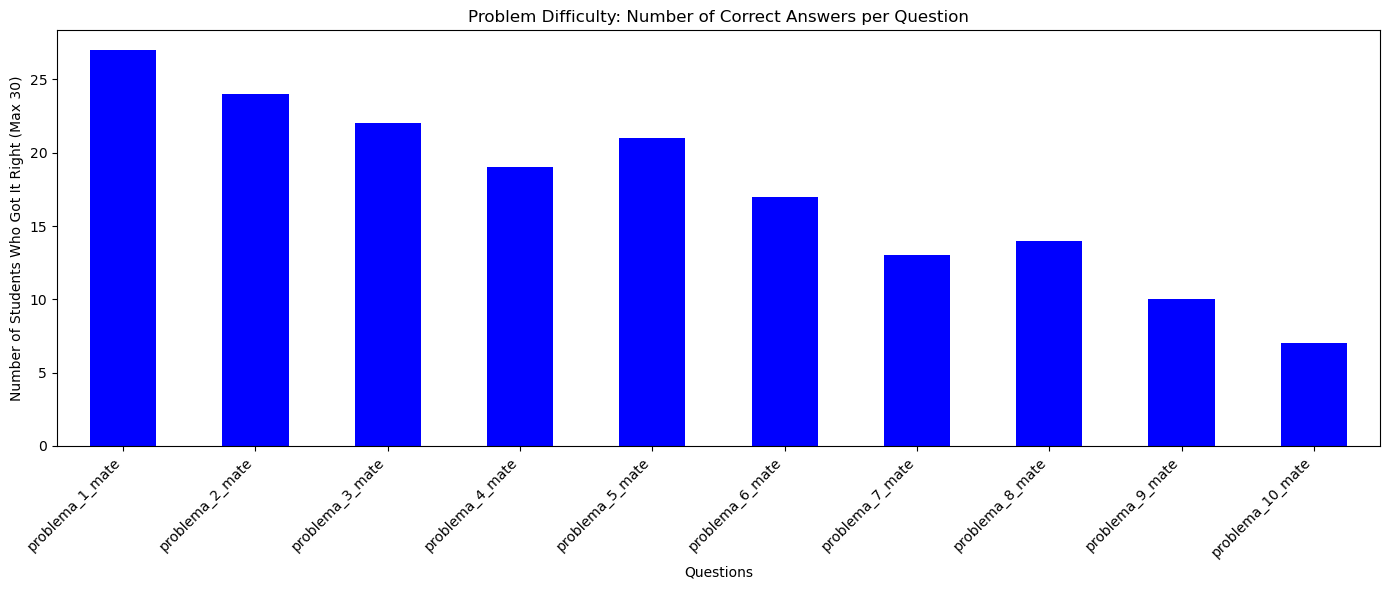

In [174]:
math_answers = final_df.iloc[:, 6:16] 
math_correct = math_answers == mate_answer_key.values

math_problem_scores = math_correct.sum(axis=0)

plt.figure(figsize=(14, 6))

math_problem_scores.plot(kind='bar', color='blue')

plt.title('Problem Difficulty: Number of Correct Answers per Question')
plt.ylabel('Number of Students Who Got It Right (Max 30)')
plt.xlabel('Questions')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

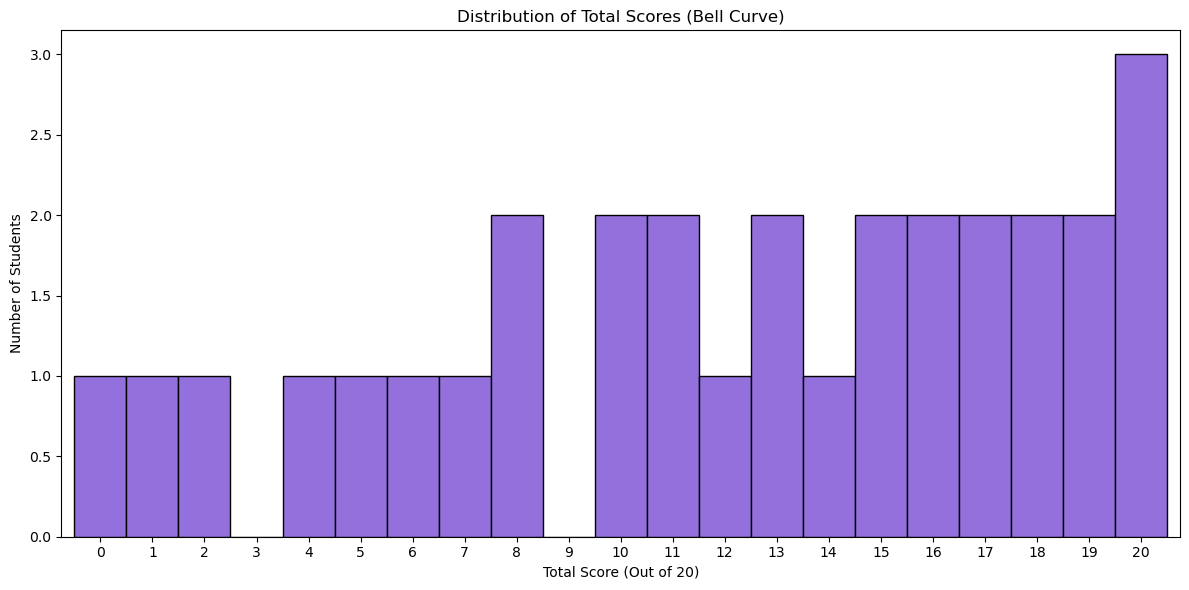

In [ ]:

score_counts = final_df['scor_total'].value_counts()

all_possible_scores = range(0, 21) 
score_distribution = score_counts.reindex(all_possible_scores, fill_value=0)

plt.figure(figsize=(12, 6))

score_distribution.plot(kind='bar', color='mediumpurple', edgecolor='black', width=1.0)

plt.title('Distribution of Total Scores')
plt.xlabel('Total Score (Out of 20)')
plt.ylabel('Number of Students')

plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()